BÀI 1: DOANH THU SIÊU THỊ
                 revenue
date                    
2023-01-01  24483.570765
2023-01-02  19308.678494
2023-01-03  23238.442691
2023-01-04  27615.149282
2023-01-05  18829.233126
revenue    10
dtype: int64
revenue    0
dtype: int64
                 revenue  year  month  quarter day_of_week  is_weekend  \
date                                                                     
2023-01-01  24483.570765  2023      1        1      Sunday        True   
2023-01-02  19308.678494  2023      1        1      Monday       False   
2023-01-03  23238.442691  2023      1        1     Tuesday       False   
2023-01-04  27615.149282  2023      1        1   Wednesday       False   
2023-01-05  18829.233126  2023      1        1    Thursday       False   

           day_type  
date                 
2023-01-01  Weekend  
2023-01-02  Weekday  
2023-01-03  Weekday  
2023-01-04  Weekday  
2023-01-05  Weekday  


/tmp/ipykernel_1999/1295693144.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df1["revenue"].resample("M").sum()


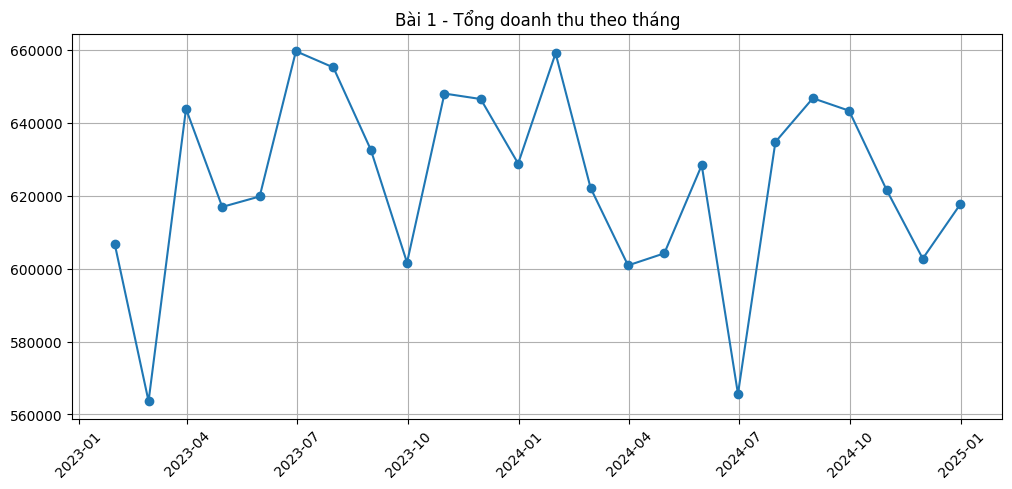

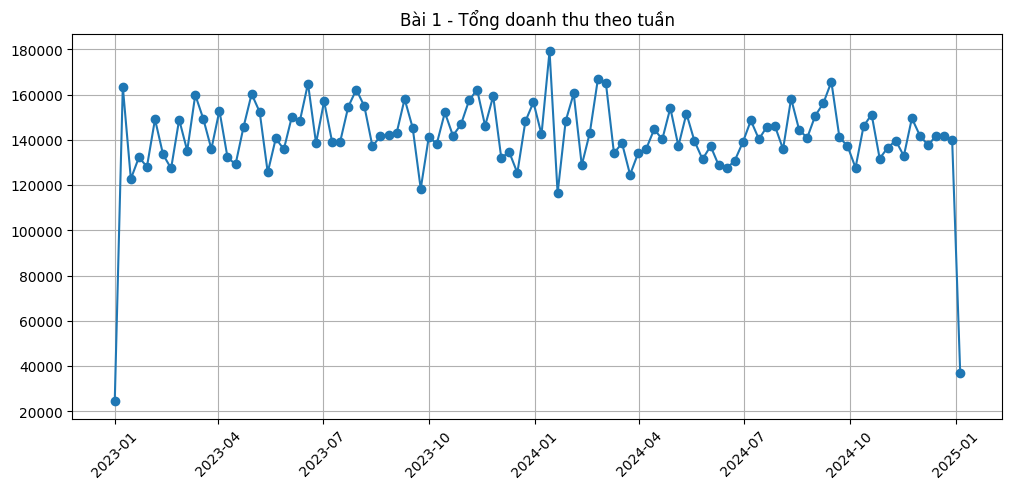

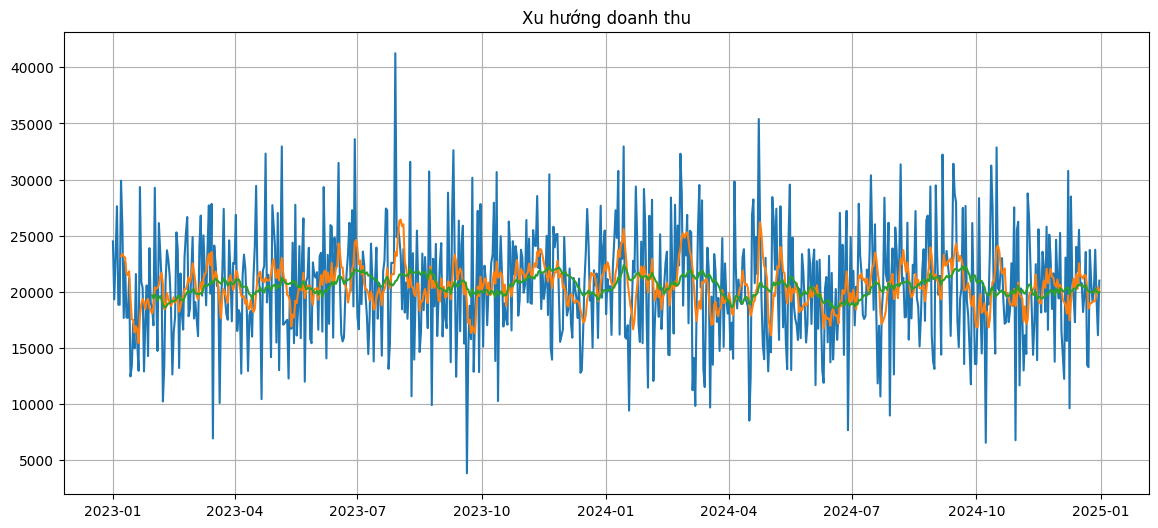

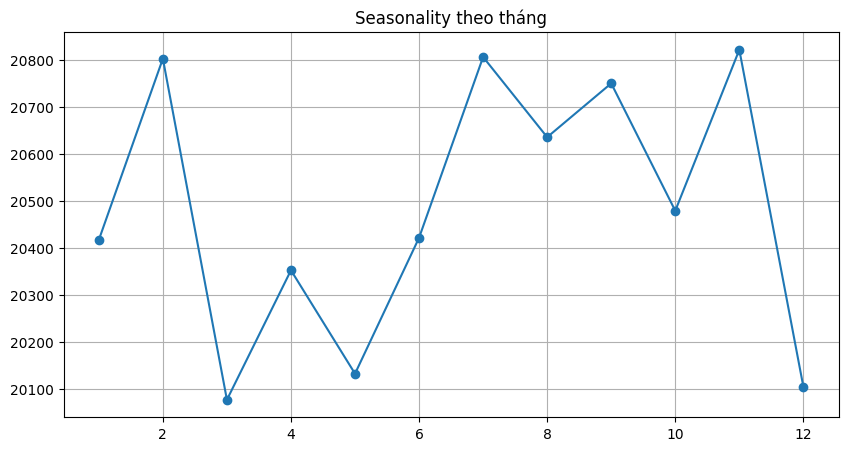

BÀI 2: LƯU LƯỢNG WEBSITE
                     visits
datetime                   
2023-01-01 00:00:00    60.0
2023-01-01 01:00:00    59.0
2023-01-01 02:00:00    46.0
2023-01-01 03:00:00    46.0
2023-01-01 04:00:00    52.0
visits    5
dtype: int64
visits    0
dtype: int64
                     visits  hour day_of_week
datetime                                     
2023-01-01 00:00:00    60.0     0      Sunday
2023-01-01 01:00:00    59.0     1      Sunday
2023-01-01 02:00:00    46.0     2      Sunday
2023-01-01 03:00:00    46.0     3      Sunday
2023-01-01 04:00:00    52.0     4      Sunday


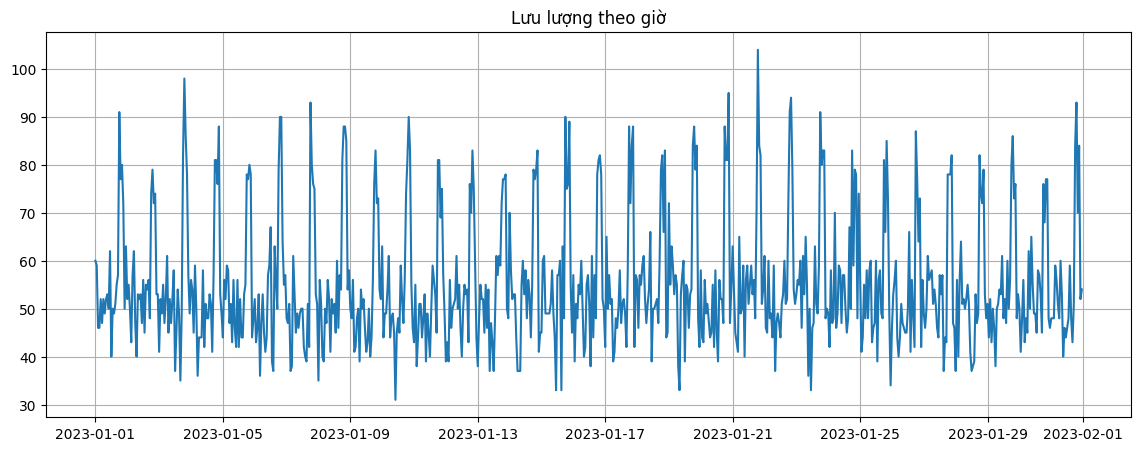

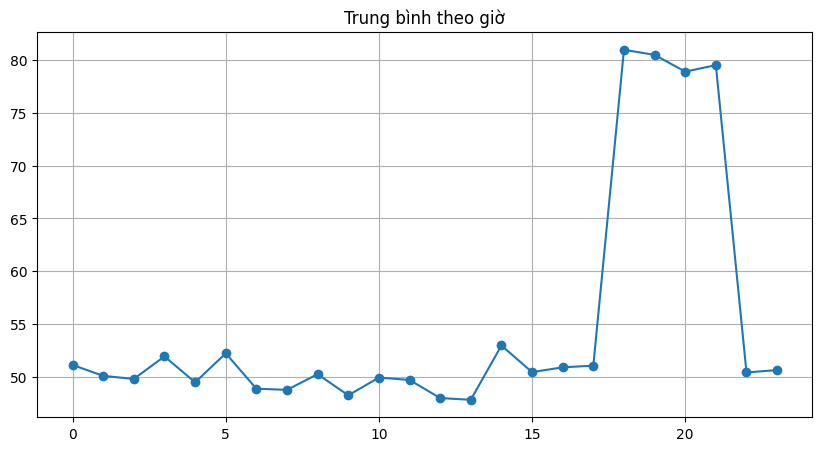

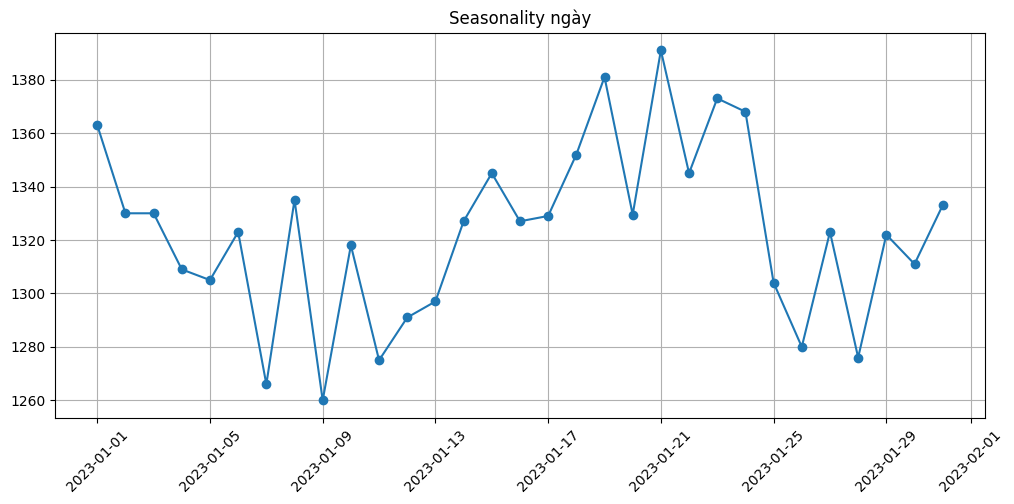

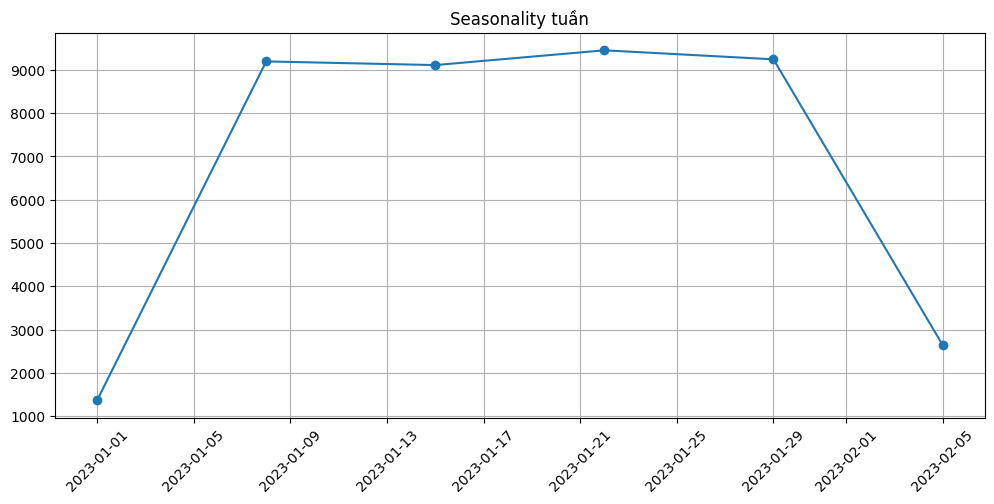

BÀI 3: GIÁ CỔ PHIẾU
            close_price
date                   
2018-01-01    98.543254
2018-01-02   102.716604
2018-01-03   100.354039
2018-01-04   100.502475
2018-01-05   101.819018
close_price    5
dtype: int64
close_price    0
dtype: int64


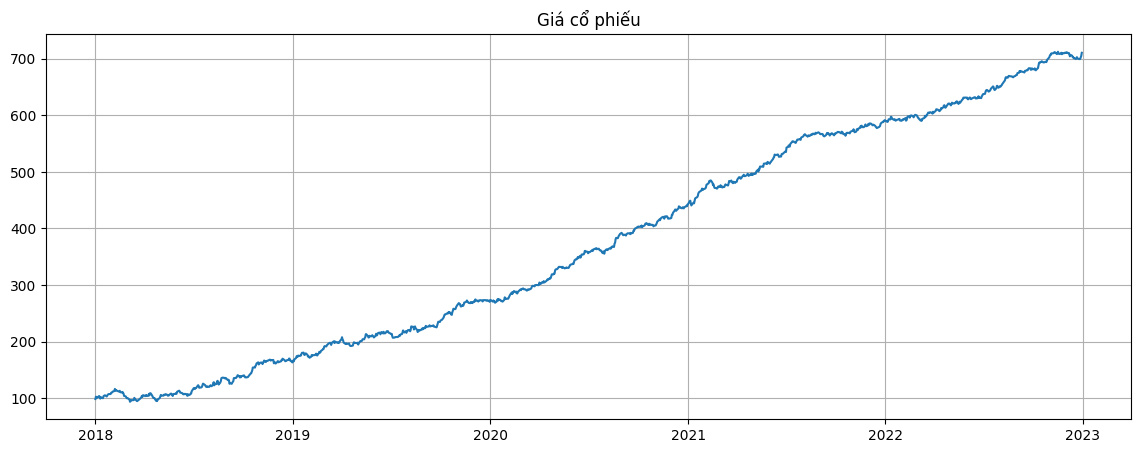

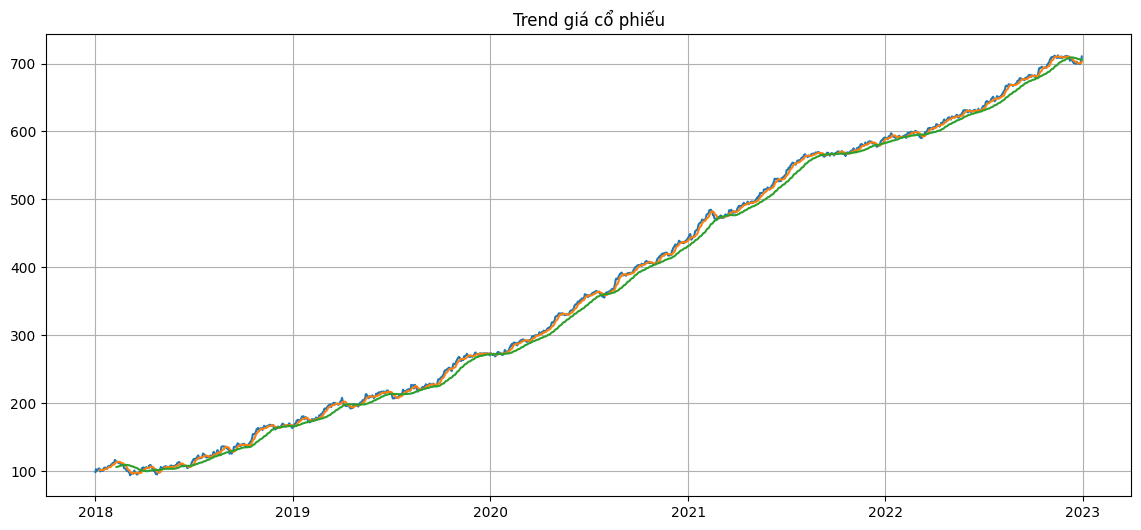

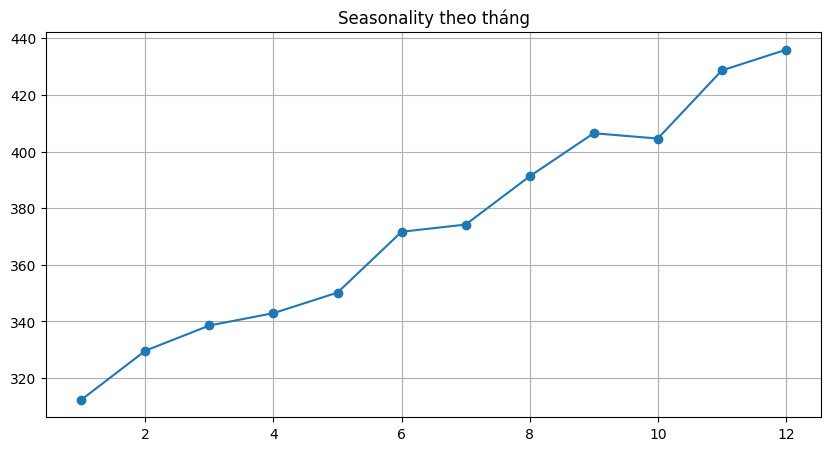

BÀI 4: SẢN XUẤT
            production
week_start            
2020-01-05  488.018117
2020-01-12  458.122190
2020-01-19  655.333024
2020-01-26  641.815208
2020-02-02  452.724275
production    5
dtype: int64
production    0
dtype: int64
            production  week  quarter  year
week_start                                 
2020-01-05  488.018117     1        1  2020
2020-01-12  458.122190     2        1  2020
2020-01-19  655.333024     3        1  2020
2020-01-26  641.815208     4        1  2020
2020-02-02  452.724275     5        1  2020


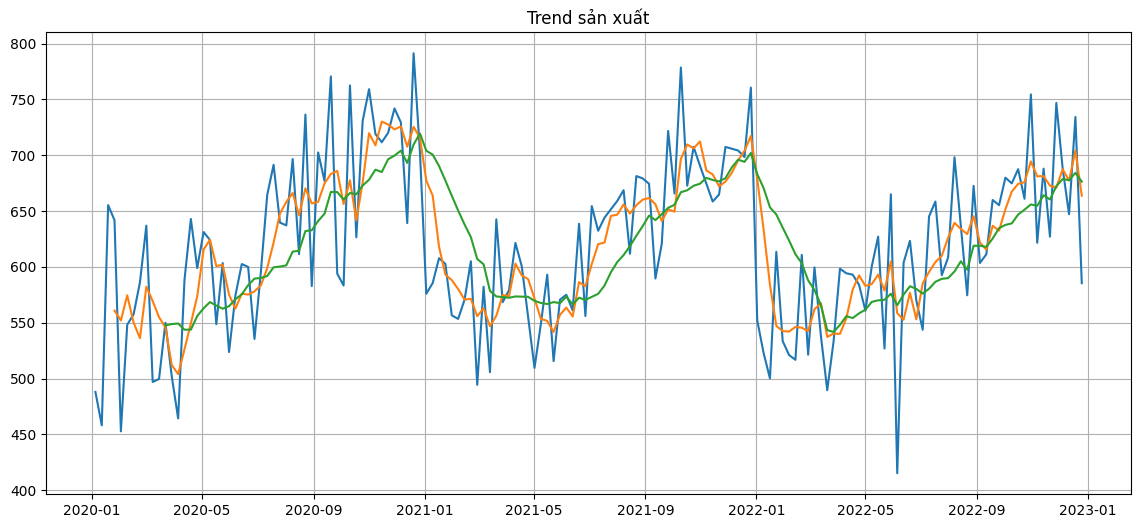

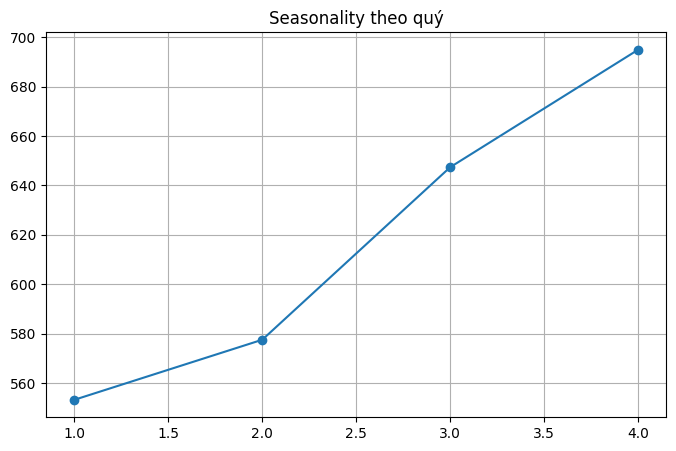

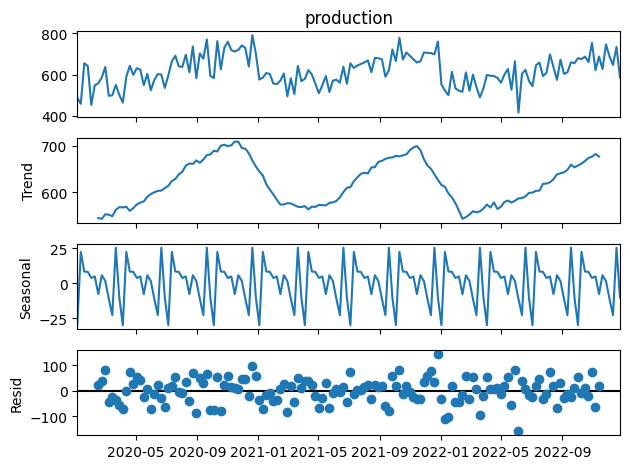

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

print("=" * 50)
print("BÀI 1: DOANH THU SIÊU THỊ")
print("=" * 50)

df1 = pd.read_csv("ITA105_Lab_5_Supermarket.csv")
df1["date"] = pd.to_datetime(df1["date"])
df1 = df1.sort_values("date")
df1.set_index("date", inplace=True)

print(df1.head())
print(df1.isnull().sum())

df1["revenue"] = df1["revenue"].interpolate(method="linear")
df1["revenue"] = df1["revenue"].ffill().bfill()

print(df1.isnull().sum())

df1["year"] = df1.index.year
df1["month"] = df1.index.month
df1["quarter"] = df1.index.quarter
df1["day_of_week"] = df1.index.day_name()
df1["is_weekend"] = df1.index.weekday >= 5
df1["day_type"] = df1["is_weekend"].map({True: "Weekend", False: "Weekday"})

print(df1.head())

monthly_revenue = df1["revenue"].resample("M").sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Bài 1 - Tổng doanh thu theo tháng")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

weekly_revenue = df1["revenue"].resample("W").sum()

plt.figure(figsize=(12, 5))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker="o")
plt.title("Bài 1 - Tổng doanh thu theo tuần")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

df1["rolling_mean_7"] = df1["revenue"].rolling(window=7).mean()
df1["rolling_mean_30"] = df1["revenue"].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1["revenue"])
plt.plot(df1.index, df1["rolling_mean_7"])
plt.plot(df1.index, df1["rolling_mean_30"])
plt.title("Xu hướng doanh thu")
plt.grid(True)
plt.show()

seasonality_month = df1.groupby("month")["revenue"].mean()

plt.figure(figsize=(10, 5))
plt.plot(seasonality_month.index, seasonality_month.values, marker="o")
plt.title("Seasonality theo tháng")
plt.grid(True)
plt.show()


print("=" * 50)
print("BÀI 2: LƯU LƯỢNG WEBSITE")
print("=" * 50)

df2 = pd.read_csv("ITA105_Lab_5_Web_traffic.csv")
df2["datetime"] = pd.to_datetime(df2["datetime"])
df2 = df2.sort_values("datetime")
df2.set_index("datetime", inplace=True)

print(df2.head())
print(df2.isnull().sum())

df2 = df2.asfreq("h")
df2["visits"] = df2["visits"].interpolate(method="linear")

print(df2.isnull().sum())

df2["hour"] = df2.index.hour
df2["day_of_week"] = df2.index.day_name()

print(df2.head())

plt.figure(figsize=(14, 5))
plt.plot(df2.index, df2["visits"])
plt.title("Lưu lượng theo giờ")
plt.grid(True)
plt.show()

hourly_pattern = df2.groupby("hour")["visits"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.title("Trung bình theo giờ")
plt.grid(True)
plt.show()

daily_pattern = df2.resample("D")["visits"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_pattern.index, daily_pattern.values, marker="o")
plt.title("Seasonality ngày")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

weekly_pattern = df2.resample("W")["visits"].sum()

plt.figure(figsize=(12, 5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker="o")
plt.title("Seasonality tuần")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


print("=" * 50)
print("BÀI 3: GIÁ CỔ PHIẾU")
print("=" * 50)

df3 = pd.read_csv("ITA105_Lab_5_Stock.csv")
df3["date"] = pd.to_datetime(df3["date"])
df3 = df3.sort_values("date")
df3.set_index("date", inplace=True)

print(df3.head())
print(df3.isnull().sum())

df3["close_price"] = df3["close_price"].ffill()

print(df3.isnull().sum())

plt.figure(figsize=(14, 5))
plt.plot(df3.index, df3["close_price"])
plt.title("Giá cổ phiếu")
plt.grid(True)
plt.show()

df3["rolling_mean_7"] = df3["close_price"].rolling(window=7).mean()
df3["rolling_mean_30"] = df3["close_price"].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(df3.index, df3["close_price"])
plt.plot(df3.index, df3["rolling_mean_7"])
plt.plot(df3.index, df3["rolling_mean_30"])
plt.title("Trend giá cổ phiếu")
plt.grid(True)
plt.show()

df3["month"] = df3.index.month
monthly_pattern = df3.groupby("month")["close_price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o")
plt.title("Seasonality theo tháng")
plt.grid(True)
plt.show()


print("=" * 50)
print("BÀI 4: SẢN XUẤT")
print("=" * 50)

df4 = pd.read_csv("ITA105_Lab_5_Production.csv")
df4["week_start"] = pd.to_datetime(df4["week_start"])
df4 = df4.sort_values("week_start")
df4.set_index("week_start", inplace=True)

print(df4.head())
print(df4.isnull().sum())

df4["production"] = df4["production"].interpolate(method="linear")
df4["production"] = df4["production"].ffill().bfill()

print(df4.isnull().sum())

df4["week"] = df4.index.isocalendar().week
df4["quarter"] = df4.index.quarter
df4["year"] = df4.index.year

print(df4.head())

df4["rolling_mean_4"] = df4["production"].rolling(window=4).mean()
df4["rolling_mean_12"] = df4["production"].rolling(window=12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df4.index, df4["production"])
plt.plot(df4.index, df4["rolling_mean_4"])
plt.plot(df4.index, df4["rolling_mean_12"])
plt.title("Trend sản xuất")
plt.grid(True)
plt.show()

quarter_pattern = df4.groupby("quarter")["production"].mean()

plt.figure(figsize=(8, 5))
plt.plot(quarter_pattern.index, quarter_pattern.values, marker="o")
plt.title("Seasonality theo quý")
plt.grid(True)
plt.show()

result = seasonal_decompose(df4["production"], model="additive", period=13)
result.plot()
plt.show()